In [1]:
print('hello')

hello


In [3]:
import pandas as pd

df = pd.read_csv("../data/churn.csv")

print(df.head())

   Year  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0  2025    15634602  Hargrave          619    France  Female   42       2   
1  2025    15647311      Hill          608     Spain  Female   41       1   
2  2025    15619304      Onio          502    France  Female   42       8   
3  2025    15701354      Boni          699    France  Female   39       1   
4  2025    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1        101348.88   
1   83807.86              1          0               1        112542.58   
2  159660.80              3          1               0        113931.57   
3       0.00              2          0               0         93826.63   
4  125510.82              1          1               1         79084.10   

   Exited  
0       1  
1       0  
2       1  
3       0  
4       0  


In [4]:
print(df.shape)

(10000, 14)


In [5]:
print(df.columns)

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [7]:
df = df.drop(['Year', 'CustomerId', 'Surname'], axis=1)

print(df.head())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


Matplotlib is building the font cache; this may take a moment.


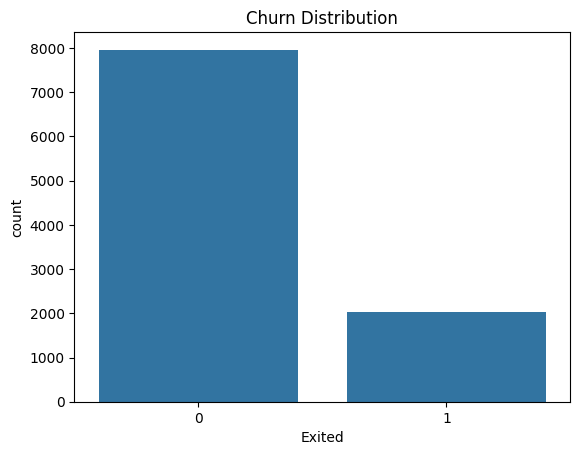

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)

plt.title("Churn Distribution")

plt.show()

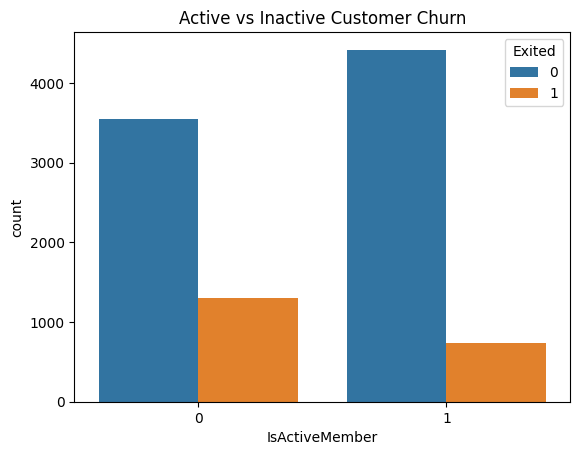

In [9]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)

plt.title("Active vs Inactive Customer Churn")

plt.show()

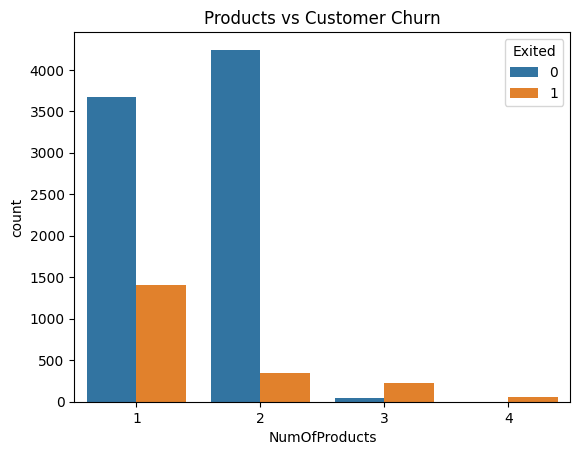

In [10]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)

plt.title("Products vs Customer Churn")

plt.show()

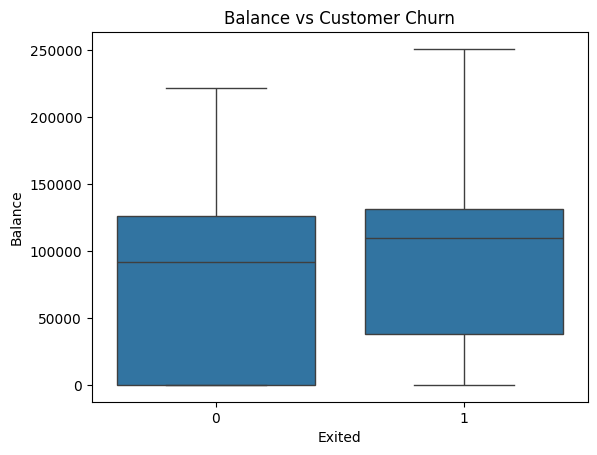

In [11]:
sns.boxplot(x='Exited', y='Balance', data=df)

plt.title("Balance vs Customer Churn")

plt.show()

In [12]:
def engagement_profile(row):

    if row['IsActiveMember'] == 1 and row['NumOfProducts'] >= 2:
        return "Highly Engaged"

    elif row['IsActiveMember'] == 0 and row['Balance'] > 100000:
        return "High Value Disengaged"

    elif row['NumOfProducts'] == 1:
        return "Low Product User"

    else:
        return "Moderate"


df['EngagementProfile'] = df.apply(engagement_profile, axis=1)

print(df[['EngagementProfile']].head())

       EngagementProfile
0       Low Product User
1       Low Product User
2  High Value Disengaged
3               Moderate
4       Low Product User


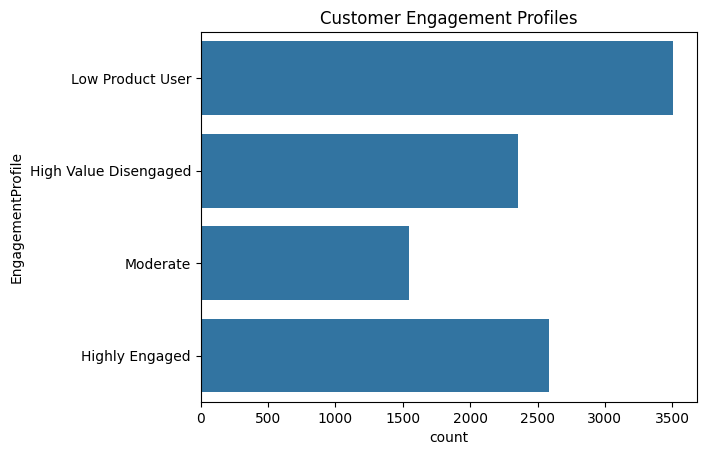

In [13]:
sns.countplot(y='EngagementProfile', data=df)

plt.title("Customer Engagement Profiles")

plt.show()

In [14]:
pip install plotly

  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/90/ad/cba91b3bcf04073e4d1655a5c1710ef3f457f56f7d1b79dcc3d72f4dd912/plotly-6.7.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 1.7 MB/s eta 0:00:06
   ---------------------------------------- 0.1/9.9 MB 1.7 MB/s eta 0:00:06
   ---------------------------------------- 0.1/9.9 MB 1.7 MB/s eta 0:00:06
   - -------------------------------------- 0.4/9.9 MB 2.5 MB/s eta 0:00:04
   --- ------------------------------------ 0.9/9.9 MB 4.2 MB/s eta 0:00:03
   ---- ----------------------------------- 1.1/9.9 MB 4.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 4.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 4.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.9 MB 4.0 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import plotly.express as px
import plotly.graph_objects as go

theme = "plotly_dark"

In [16]:
fig = px.histogram(
    df,
    x='Exited',
    color='Exited',
    text_auto=True,
    title='Customer Churn Distribution',
    template=theme
)

fig.update_layout(
    xaxis_title='Churn Status',
    yaxis_title='Customer Count'
)

fig.show()

In [17]:
fig = px.histogram(
    df,
    x='IsActiveMember',
    color='Exited',
    barmode='group',
    text_auto=True,
    title='Customer Engagement vs Churn',
    template=theme
)

fig.update_layout(
    xaxis_title='Is Active Member',
    yaxis_title='Customer Count'
)

fig.show()

In [18]:
fig = px.histogram(
    df,
    x='NumOfProducts',
    color='Exited',
    barmode='group',
    text_auto=True,
    title='Product Utilization vs Churn',
    template=theme
)

fig.update_layout(
    xaxis_title='Number of Products',
    yaxis_title='Customer Count'
)

fig.show()

In [19]:
fig = px.histogram(
    df,
    x='Geography',
    color='Exited',
    barmode='group',
    text_auto=True,
    title='Geography-wise Churn Analysis',
    template=theme
)

fig.show()

In [20]:
fig = px.box(
    df,
    x='Exited',
    y='Balance',
    color='Exited',
    title='Balance vs Customer Churn',
    template=theme
)

fig.show()

In [21]:
fig = px.histogram(
    df,
    y='EngagementProfile',
    color='EngagementProfile',
    text_auto=True,
    title='Customer Engagement Profiles',
    template=theme
)

fig.show()

In [22]:
total_customers = df.shape[0]

churn_rate = (df['Exited'].sum() / total_customers) * 100

active_customers = df['IsActiveMember'].sum()

inactive_customers = total_customers - active_customers

high_risk_customers = df[
    (df['IsActiveMember'] == 0) &
    (df['Balance'] > 100000)
].shape[0]

print("Total Customers:", total_customers)

print("Churn Rate:", round(churn_rate, 2), "%")

print("Active Customers:", active_customers)

print("Inactive Customers:", inactive_customers)

print("High Risk Customers:", high_risk_customers)

Total Customers: 10000
Churn Rate: 20.37 %
Active Customers: 5151
Inactive Customers: 4849
High Risk Customers: 2356


In [23]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
streamlit --version

NameError: name 'streamlit' is not defined